In [1]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import BatchNormalization

class AlexNet:
    @staticmethod
    def build(input_shape=(224,224,3), activation='relu', class_num=1000):
        model = Sequential()
        model.add(Input(shape=input_shape))

        model.add(Conv2D(96, (11,11), strides=(4,4),
                         activation=activation, padding="same"))
        model.add(MaxPooling2D(pool_size=(3,3), strides=2))
        model.add(BatchNormalization())

        model.add(Conv2D(256, (5,5), activation=activation, padding="same"))
        model.add(MaxPooling2D(pool_size=(3,3), strides=2))
        model.add(BatchNormalization())

        model.add(Conv2D(384, (3,3), activation=activation, padding="same"))
        model.add(Conv2D(384, (3,3), activation=activation, padding="same"))
        model.add(Conv2D(256, (3,3), activation=activation, padding="same"))

        model.add(Flatten())
        model.add(Dense(4096, activation=activation))
        model.add(Dense(4096, activation=activation))
        model.add(Dense(class_num, activation='softmax'))

        return model


I0000 00:00:1779514757.429061   22320 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779514757.476020   22320 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779514758.407660   22320 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
model = AlexNet.build(input_shape=(32,32,3), class_num=10)
model.summary()

W0000 00:00:1779514762.642311   22320 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1779514762.662376   22320 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1779514762.772943   22320 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 29802 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5090, pci bus id: 0000:01:00.0, compute capability: 12.0a


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 8, 8, 96)       │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 3, 3, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 3, 3, 96)       │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 3, 3, 256)      │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 1, 1, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1, 1, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 1, 1, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 1, 1, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 1, 1, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │     1,052,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,623,562 (82.49 MB)

 Trainable params: 21,622,858 (82.48 MB)

 Non-trainable params: 704 (2.75 KB)

In [5]:
model.compile(loss='sparse_categorical_crossentropy',
              optimizer='adam', metrics=['accuracy'])

In [6]:
from tensorflow.keras.datasets import cifar10
(train_X, train_y), (test_X, test_y) = cifar10.load_data()

model.fit(train_X, train_y, validation_data=(test_X, test_y),
                    batch_size=200, epochs=10, verbose=1)

Epoch 1/10


I0000 00:00:1779514917.652913   22818 service.cc:153] XLA service 0x7a64ac038a10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779514917.652951   22818 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5090, Compute Capability 12.0a (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.19.0)
I0000 00:00:1779514917.715935   22818 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1779514917.983667   22818 cuda_dnn.cc:461] Loaded cuDNN version 91900
I0000 00:00:1779514918.011925   22818 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3681__.42
I0000 00:00:1779514918.270567   23255 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_22', 16 bytes spill stores, 8 bytes spill loads

I0000 00:00:1779514919.006627   23247 subprocess_compilation.cc:348] ptxas warn

 40/250 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1727 - loss: 2.1282

I0000 00:00:1779514926.907061   22818 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


250/250 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.3729 - loss: 1.6622 - val_accuracy: 0.3207 - val_loss: 2.3136
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5256 - loss: 1.3244 - val_accuracy: 0.4441 - val_loss: 1.6674
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5932 - loss: 1.1539 - val_accuracy: 0.4978 - val_loss: 1.5447
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6398 - loss: 1.0230 - val_accuracy: 0.5079 - val_loss: 1.4719
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6856 - loss: 0.9054 - val_accuracy: 0.5938 - val_loss: 1.1880
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7225 - loss: 0.8036 - val_accuracy: 0.5646 - val_loss: 1.4095
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7541 - loss: 0.7115 - val_accuracy: 0.5673 - val_loss: 1.4833
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7835 - loss: 0.6304 - val_accuracy: 0.5869 - va

### 결과 테이블 
합성곱 층(Conv2D)에 padding="same" 옵션이 적용되어 있으므로, 합성곱 연산 자체로는 가로·세로 크기가 줄어들지 않고 오직 스트라이드(Strides)와 맥스풀링(MaxPooling2D)에 의해서만 크기가 줄어든다

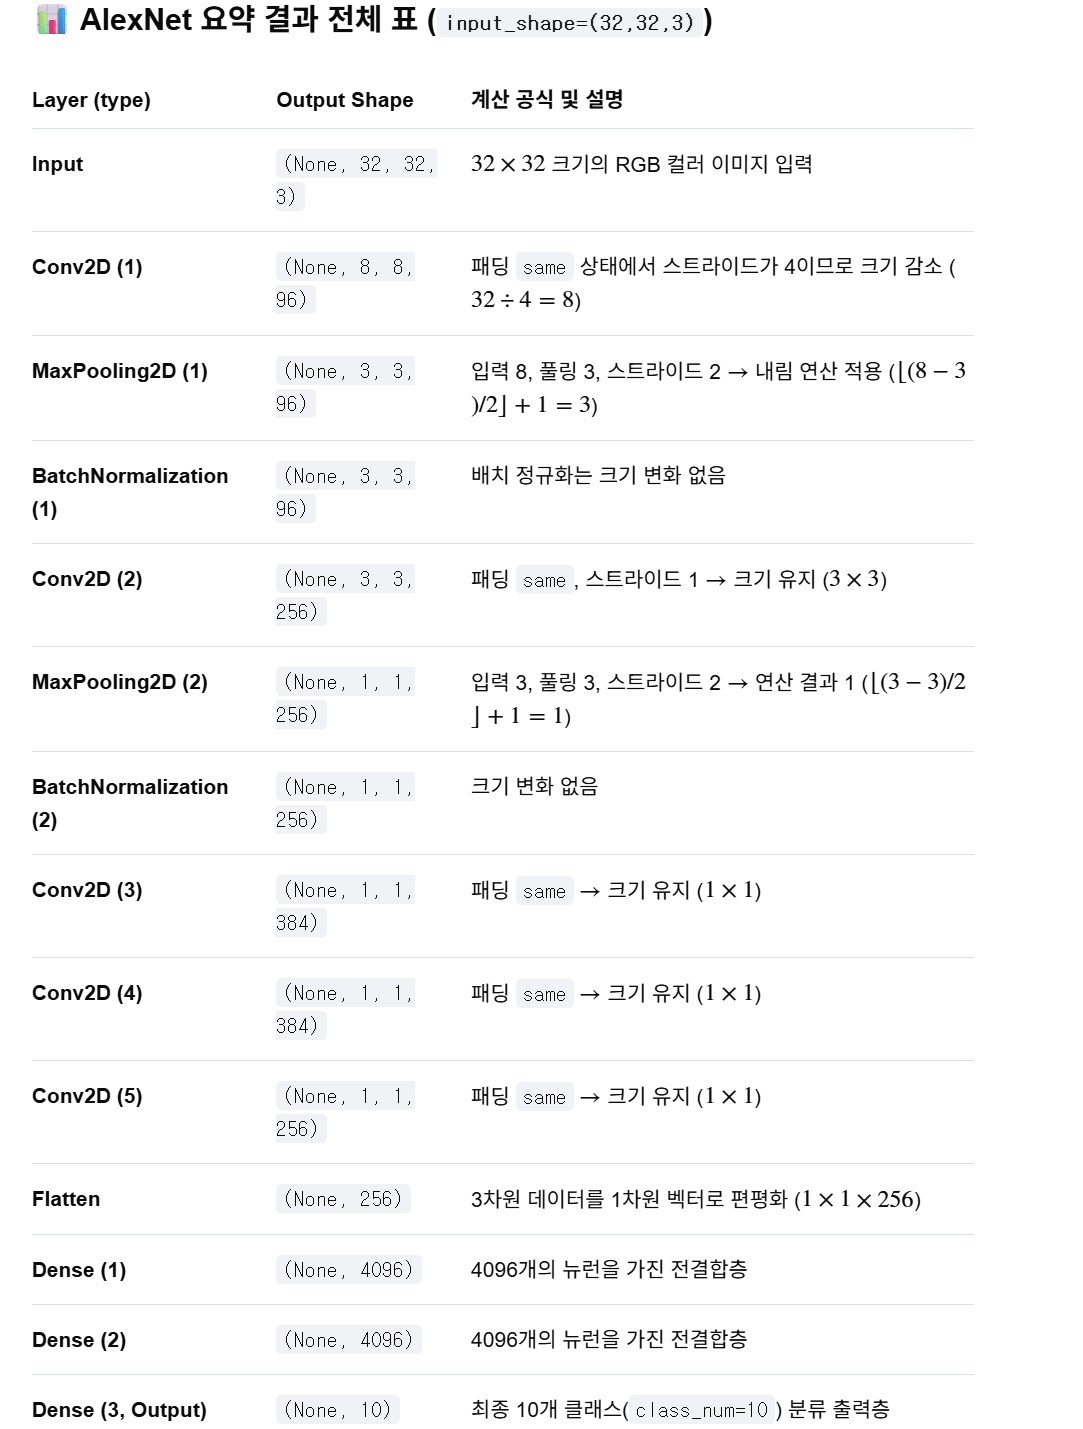

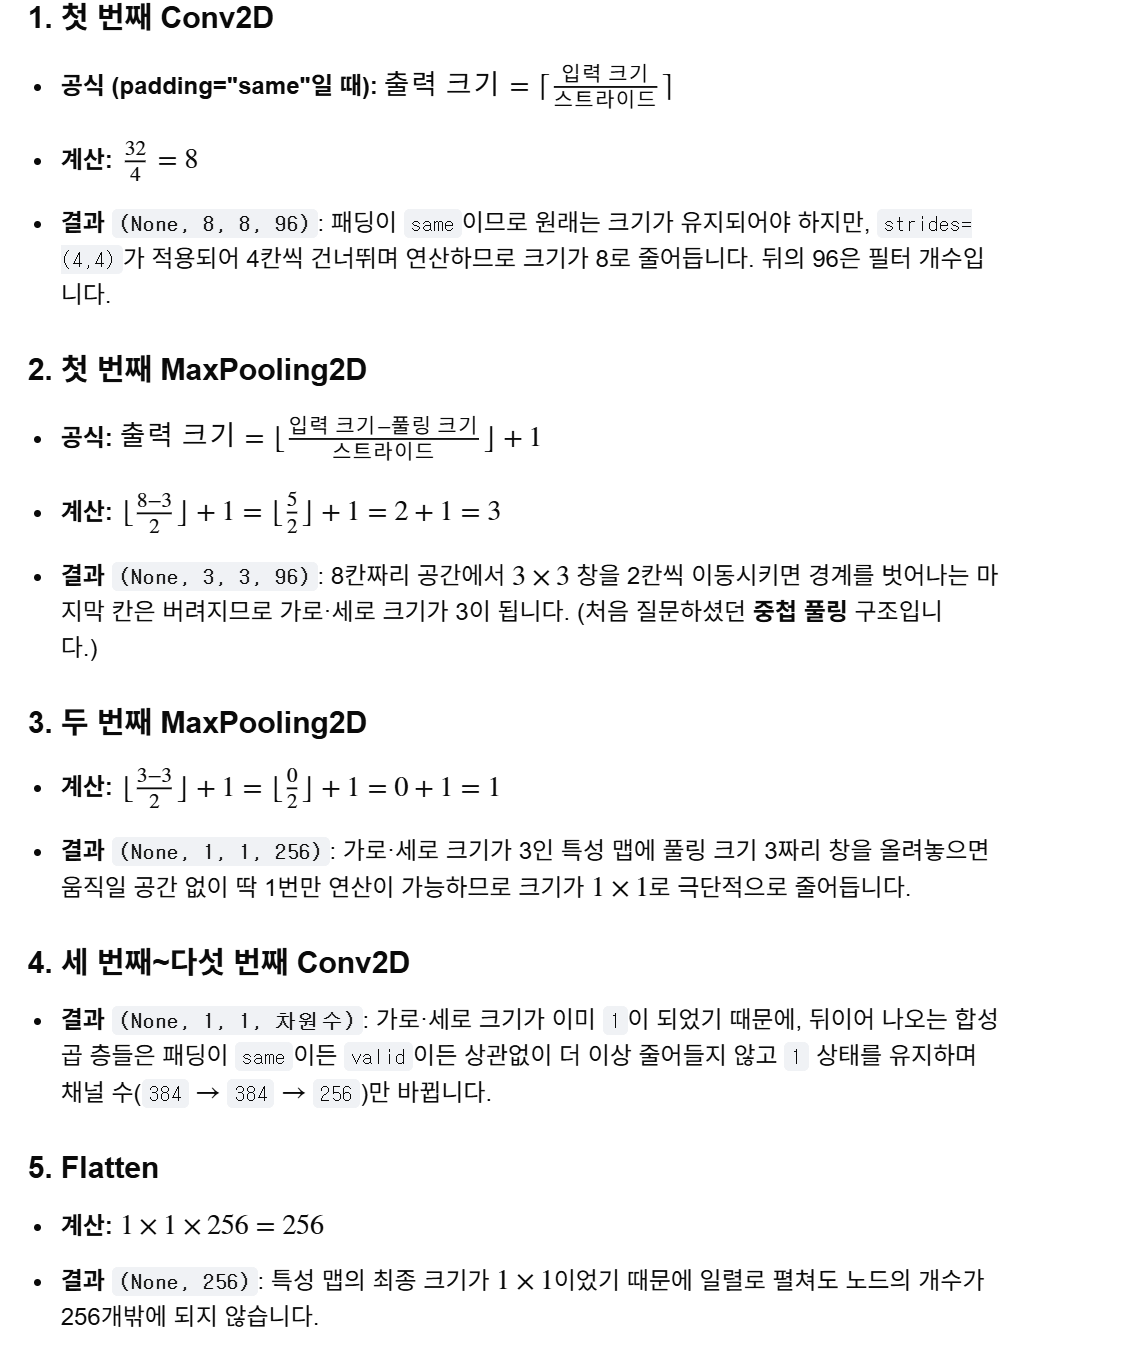

In [7]:
loss, accuracy = model.evaluate(test_X, test_y, verbose=1)
print(f"Loss: {loss}, Accuracy: {accuracy*100}%")

I0000 00:00:1779514961.467606   31867 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_8', 4 bytes spill stores, 4 bytes spill loads



299/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5652 - loss: 1.6624

I0000 00:00:1779514964.284616   32151 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_8', 4 bytes spill stores, 4 bytes spill loads



313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.5593 - loss: 1.6764
Loss: 1.6764479875564575, Accuracy: 55.93000054359436%
